In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

mpl.rcdefaults()
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "mathtext.fontset": "cm",   # LaTeX-like only for math text
    "axes.unicode_minus": False,
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 240,
})

In [2]:
data_path = Path("Qcap_sinf_N1000_g1.5_dt0.2_T10000_ens100_m01_wauto.npz")
# If you put the file elsewhere, edit the path above (or use an absolute path).

if not data_path.exists():
    raise FileNotFoundError(
        f"{data_path} not found. Check the path and filename "
        f"(this notebook expects the schema produced by run_and_save_Q_capacity.py "
        f"or merge_Q_capacity_chunks.py)."
    )

d = np.load(data_path, allow_pickle=True)
alpha       = np.asarray(d['alpha_vals'])      # P/N grid
q           = np.asarray(d['q_vals'])          # Q/N grid
overlap_map = np.asarray(d['overlap_map'])     # shape (n_alpha, n_q)
msd_map     = np.asarray(d['msd_map'])         # shape (n_alpha, n_q)
m0          = float(d['init_overlap'])

print(f"file:        {data_path.name}")
print(f"alpha grid:  {len(alpha)} pts, range [{alpha.min():.3g}, {alpha.max():.3g}]")
print(f"Q/N grid:    {len(q)} pts,   range [{q.min():.3g}, {q.max():.3g}]")
print(f"shape:       overlap_map={overlap_map.shape}, msd_map={msd_map.shape}")
print(f"m0 (init):   {m0:g}")
print(f"overlap range: [{np.nanmin(overlap_map):.3f}, {np.nanmax(overlap_map):.3f}]")
print(f"MSD range:     [{np.nanmin(msd_map):.3f}, {np.nanmax(msd_map):.3f}]")
if np.any(np.isnan(overlap_map)) or np.any(np.isnan(msd_map)):
    print("WARNING: NaNs present (likely a missing chunk in the merge).")


file:        Qcap_sinf_N1000_g1.5_dt0.2_T10000_ens100_m01_wauto.npz
alpha grid:  31 pts, range [0.01, 0.6]
Q/N grid:    21 pts,   range [0, 1]
shape:       overlap_map=(31, 21), msd_map=(31, 21)
m0 (init):   1
overlap range: [0.704, 1.000]
MSD range:     [0.000, 0.563]


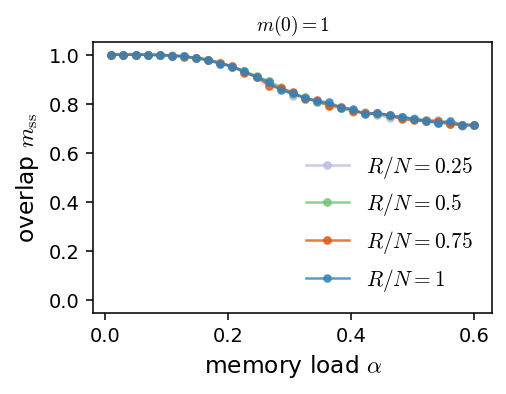

In [8]:
# cuts at fixed R/N (one curve per chosen q-index)
chosen_q_indices = np.linspace(0, len(q) - 1, 5).round().astype(int)

fig, ax = plt.subplots(figsize=(3.5,2.7), constrained_layout=True)
cmap = plt.get_cmap('tab20c_r')
for k, j in enumerate(chosen_q_indices):
    if j != 0:
        c = cmap(k / max(1, len(chosen_q_indices) - 1))
        ax.plot(alpha, overlap_map[:, j], '-o', ms=3.5, lw=1.3, color=c, alpha=0.78,
                label=fr'$R/N = {q[j]:.2g}$')
ax.set_xlabel(r'memory load $\alpha$')
ax.set_ylabel(r'overlap $ m_\mathrm{ss}$')
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, loc='lower right', ncol=1)
ax.set_title(rf'$m(0) = {m0:g}$')
plt.show()


In [10]:
fig.savefig(
    "overlap_rankW.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

# High-resolution raster version: useful for preview/submission
fig.savefig(
    "overlap_rankW.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()